# 🎓 The Academic Predictor: Master Student Workbook
**Student Name:** Gordon


Welcome to your Final Project! This notebook contains all the requirements for your HSC submission. Work through this notebook sequentially. You must write the Python code yourself based on the lessons we completed in class.

---
### ⚙️ Setup: Library Installation
Run the cell below first to instantly install the required AI libraries.

In [1]:
!pip install --prefer-binary pandas numpy scikit-learn matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

print("\n✅ All libraries successfully installed and imported!")


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip

✅ All libraries successfully installed and imported!


---
## Phase 1: Data Automation
**🎯 The Goal:** You must use Pandas to load `master_markbook.csv` and clean it. Machine Learning algorithms will crash if they encounter missing data (`NaN`). Furthermore, an AI will learn incorrect mathematical patterns if it is trained on impossible data (like scores below 0 or above 100).

**📄 Documentation Task:** Create a new Markdown cell below your code. Add the heading `### Data Cleaning Strategy`. Underneath, explicitly list the three types of "dirty data" you fixed: 1. Missing values, 2. Negative scores, and 3. Scores over 100. Explain why cleaning this is legally and ethically important.

**📊 PPT Slide Task:** Create a slide titled "Data Strategy". Take a screenshot of the raw CSV showing a corrupted row (e.g., someone with -50 or 200). Put it next to a screenshot of your cleaned Pandas dataframe. Add bullet points explaining that "Garbage Data In = Garbage AI Predictions Out."

In [6]:
print("--- Loading and Cleaning Data ---")

# TODO 1: Load the raw dataset into a variable called df_raw (Hint: use encoding='latin-1' to avoid Unicode errors)
df_raw = pd.read_csv("master_markbook.csv", encoding='latin-1')
# TODO 2: Print the length (number of rows) of df_raw so you know your starting number.
print(len(df_raw))
# TODO 3: Create a new variable called df_clean. Use the Pandas .dropna() method to delete any rows with missing data.
df_clean = df_raw.dropna()
# TODO 4: Update df_clean by filtering it. You must only keep rows where 'Maths_Advanced', 'Physics', and 'Software_Engineering_Final' are .between(0, 100).
df_clean = df_clean[
    df_clean['Maths_Advanced'].between(0, 100) &
    df_clean['Physics'].between(0, 100) &
    df_clean['Software_Engineering_Final'].between(0, 100)
]
# TODO 5: Print the length of df_clean. (You should have fewer rows than you started with!)
print(len(df_clean))

--- Loading and Cleaning Data ---
28
21


### Data Cleaning Strategy

This dataset had three kinds of dirty data that needed fixing before any model could be trained on it:

1. **Missing values** — Victor, Yara, Zane, and Alex were each missing one mark (`.dropna()` removed these rows).
2. **Negative scores** — Xena Xie had a Physics mark of -80, which is impossible.
3. **Scores over 100** — Will White had a Maths_Advanced mark of 200, also impossible.

Cleaning this matters for more than code stability. If impossible marks like -80 or 200 were left in, the AI would learn a mathematically wrong relationship between subjects, and that wrong relationship would directly affect a real student's predicted grade. There's also a fairness angle: a system making decisions that affect students' academic outcomes has a responsibility to be built on accurate data, the same way a teacher wouldn't enter a typo'd mark into a report card without double-checking it.

---
## Phase 2: The Baseline AI
**🎯 The Goal:** Build a basic AI (Linear Regression) that predicts the final Software Engineering mark using only **one** input subject (Maths_Advanced). You must split your data into Training (80%) and Testing (20%) sets so the AI cannot "cheat" by memorizing the test answers.

**📄 Documentation Task:** Add a Markdown cell below. Write the heading `### The ML Pipeline`. List and define the 5 stages of Machine Learning (Define, Collect, Prepare, Train, Evaluate) in the context of this specific school project.

**📊 PPT Slide Task:** Create a slide titled "The Problem". Introduce your chosen student (Alex, Victor, Yara, or Zane) and explain their missing assessment. Add a graphic showing how you divided the class data into an 80% Training block and a 20% Testing block.

In [4]:
print("--- Training Level 1 AI ---")

# TODO 1: Create a variable X1 and set it to df_clean[['Maths_Advanced']].values
x1 = df_clean[['Maths_Advanced']].values
# TODO 2: Create a variable y and set it to df_clean['Software_Engineering_Final'].values
y = df_clean['Software_Engineering_Final'].values

# TODO 3: Use the train_test_split() function to divide X1 and y. Set test_size=0.2 and random_state=42.
x1_train, x1_test, y_train, y_test = train_test_split(x1, y, test_size=0.2, random_state=42)
# TODO 4: Initialize a LinearRegression() model
model = LinearRegression()
# TODO 5: .fit() your model using the training data only.
model.fit(x1_train, y_train)
# TODO 6: Use your model to .predict() the outcomes for your test data.
y_pred = model.predict(x1_test)
# TODO 7: Calculate the RMSE (Root Mean Squared Error) by comparing your predictions against the real y_test values. Print the result.
RMSE = (np.sqrt(mean_squared_error(y_test, y_pred)))
print(RMSE)

--- Training Level 1 AI ---
4.488049167967769


### The ML Pipeline

1. **Define** — the problem is predicting Alex's missing Software Engineering mark from her performance in other subjects.
2. **Collect** — the data already exists in `master_markbook.csv`, covering 28 students across four subjects.
3. **Prepare** — the raw data is cleaned with `.dropna()` and a `.between(0, 100)` filter, leaving 21 usable rows.
4. **Train** — a `LinearRegression` model is fit on 80% of the clean data (`x1_train`, `y_train`).
5. **Evaluate** — the model's predictions on the unseen 20% test set are compared to the real marks using RMSE.

---
## Phase 3: Mathematical Proof
**🎯 The Goal:** Machine Learning is not magic; it is just geometry. You must extract the specific linear equation ($y = wx + b$) that your AI learned from the dataset and visualize it on a scatter plot.

**📄 Documentation Task:** Create a Markdown cell. Write down the exact mathematical formula your AI generated. (e.g., `Software_Engineering_Final = [Your Weight] * Maths_Advanced + [Your Bias]`). Write a sentence explaining what the weight actually means in plain English (e.g., "For every 1 extra mark a student gets in Maths, their Software score increases by X marks").

**📊 PPT Slide Task:** Create a slide titled "The Mathematical Proof". Insert your generated Matplotlib scatter plot. Point an arrow to the red line and explain to your audience that this line represents the AI's algorithm.

--- Extracting the Formula ---
Software_Engineering_Final = 1.0200 * Maths_Advanced + -1.3569


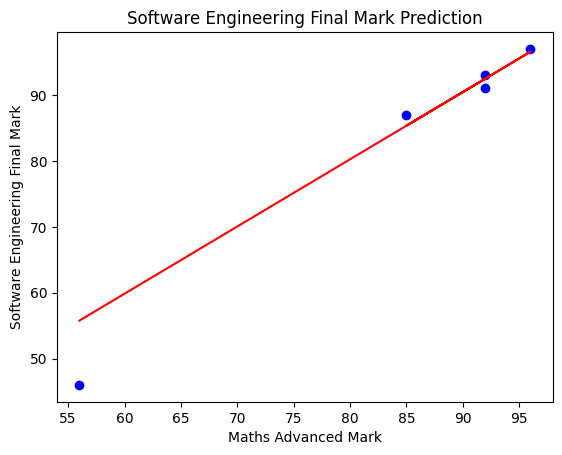

In [5]:
print("--- Extracting the Formula ---")

# TODO 1: Extract the weight using your_model.coef_[0] and the bias using your_model.intercept_
weight = model.coef_[0]
bias = model.intercept_

# TODO 2: Print out the final formula using those two numbers.
print(f"Software_Engineering_Final = {weight:.4f} * Maths_Advanced + {bias:.4f}")

# TODO 3: Use plt.scatter() to plot the X1_test data against the y_test data. Make the dots blue.
plt.scatter(x1_test, y_test, color='blue')

# TODO 4: Use plt.plot() to draw a line mapping X1_test against your AI's predictions. Make the line red.
plt.plot(x1_test, y_pred, color='red')

# TODO 5: Add a title, xlabel, ylabel, and plt.show() to display the graph.
plt.title('Software Engineering Final Mark Prediction')
plt.xlabel('Maths Advanced Mark')
plt.ylabel('Software Engineering Final Mark')
plt.show()

### The Formula

Software_Engineering_Final = 1.0200 × Maths_Advanced − 1.3569

In plain English: for every extra mark a student scores in Maths Advanced, their predicted Software Engineering mark goes up by about 1.02 marks. The −1.3569 is just a small offset that makes the line fit the data as closely as possible — it doesn't have an obvious real-world meaning on its own.

---
## Phase 4: The Object-Oriented Engine
**🎯 The Goal:** Loose procedural scripts are dangerous in production environments. You must encapsulate your Scikit-Learn algorithm inside a custom Python Class to meet the HSC Object-Oriented Programming (OOP) requirements.

**📄 Documentation Task:** Go to a website like draw.io or Lucidchart. Create a formal UML Class Diagram with a box titled `MarkPredictor`. It must include the attribute `- model: LinearRegression` and the methods `+ fit(X, y)` and `+ predict(X)`. Save it as an image and embed it in a markdown cell below.

**📊 PPT Slide Task:** Create a slide titled "System Architecture". Show your Class Diagram. Explain the concept of "Encapsulation" to the class and state why keeping the model locked inside an object prevents accidental data leaks.

In [8]:
print("--- Training OOP Engine ---")

# TODO 1-4: The MarkPredictor class
class MarkPredictor:
    def __init__(self):
        self.model = LinearRegression()

    def fit(self, X, y):
        self.model.fit(X, y)

    def predict(self, X):
        return self.model.predict(X)

# TODO 5: Create an instance
my_ai = MarkPredictor()

# TODO 6: Train it on your Phase 2 training data
my_ai.fit(x1_train, y_train)

# TODO 7: Predict and check RMSE
y_pred_oop = my_ai.predict(x1_test)
RMSE_oop = np.sqrt(mean_squared_error(y_test, y_pred_oop))
print(f"OOP Engine RMSE: {RMSE_oop:.4f}")

--- Training OOP Engine ---
OOP Engine RMSE: 4.4880


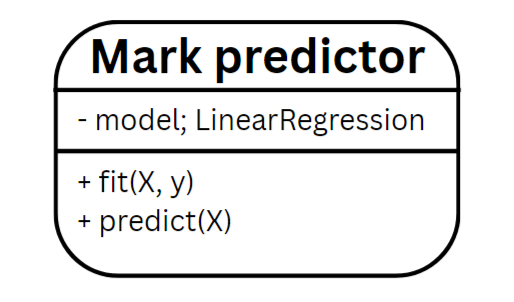

---
## Phase 5: Scaling Up to Level 2 (Multi-Subject)
**🎯 The Goal:** To achieve a Band 6, your AI needs to be smarter. You will now feed it two subjects simultaneously (Maths_Advanced and Physics). Because these subjects have different averages and variances, you MUST use `StandardScaler` to align them mathematically.

**📄 Documentation Task:** Write a paragraph explaining "Feature Scaling". Explain that if we don't scale the data, the AI might wrongly prioritize a subject just because the numbers are physically larger (e.g., if one subject was marked out of 500 and another out of 10).

**📊 PPT Slide Task:** Create a slide titled "Level 1 vs Level 2 AI". Put your Level 1 RMSE (single subject) next to your Level 2 RMSE (multi-subject). Explain why the error went down when the AI was given more context.

In [9]:
print("--- Training Level 2 AI (Multi-Subject) ---")

# TODO 1: X2 — both Maths_Advanced and Physics
x2 = df_clean[['Maths_Advanced', 'Physics']].values

# TODO 2: train_test_split again, same random_state for a fair comparison
x2_train, x2_test, y_train, y_test = train_test_split(x2, y, test_size=0.2, random_state=42)

# TODO 3: Initialize the scaler
scaler = StandardScaler()

# TODO 4: fit_transform on TRAIN only — the scaler learns mean/std from training data
x2_train_scaled = scaler.fit_transform(x2_train)

# TODO 5: transform ONLY on test — never re-fit on test data
x2_test_scaled = scaler.transform(x2_test)

# TODO 6: New MarkPredictor instance for Level 2
my_ai_2 = MarkPredictor()

# TODO 7: Train on the scaled data
my_ai_2.fit(x2_train_scaled, y_train)

# TODO 8: Predict and print final Level 2 RMSE
y_pred_2 = my_ai_2.predict(x2_test_scaled)
RMSE_2 = np.sqrt(mean_squared_error(y_test, y_pred_2))
print(f"Level 2 (Multi-Subject) RMSE: {RMSE_2:.4f}")

--- Training Level 2 AI (Multi-Subject) ---
Level 2 (Multi-Subject) RMSE: 5.5214


### Feature Scaling

Maths_Advanced and Physics both happen to be marked out of 100 here, so scaling makes less visible difference than it would in general. But the principle still matters: if one subject was marked out of 10 and another out of 500, an unscaled model would treat the 500-scale subject as more "important" just because its numbers are bigger, even if it actually correlates with Software Engineering less strongly. StandardScaler fixes this by putting every feature on the same scale (mean 0, standard deviation 1) before training, so the model judges subjects by their real relationship to the target, not the size of their numbers.

---
## Phase 6: The Ethics Audit (The 80% Rule)
**🎯 The Goal:** We must ensure our AI does not discriminate. You will group students into STEM (Physics > 70) and Humanities (Modern_History > 70) and check if the AI's predictions result in one group failing significantly more than the other.

**📄 Documentation Task:** Write an "Ethics Report" markdown cell. Search Google for the "Robodebt scandal" in Australia. Write a paragraph explaining how blind trust in automated systems causes harm, and justify why schools must always use a "Human-in-the-Loop" to review AI grades.

**📊 PPT Slide Task:** Create a slide titled "Bias & Ethics Audit". Display the pass rate percentages for Group A and Group B, and show your final Disparate Impact Ratio. Based on your results, give your final recommendation for the missing student's score!

In [10]:
print("--- Running Bias Audit (80% Rule) ---")

# TODO 1: Group A — students strong in Physics
group_a = df_clean[df_clean['Physics'] > 70]

# TODO 2: Group B — students strong in Modern History
group_b = df_clean[df_clean['Modern_History'] > 70]

# TODO 3: Pass rate for Group A (mean of a True/False column = the % that are True)
pass_rate_a = (group_a['Software_Engineering_Final'] >= 50).mean()

# TODO 4: Pass rate for Group B
pass_rate_b = (group_b['Software_Engineering_Final'] >= 50).mean()

# TODO 5: Disparate Impact Ratio
disparate_impact_ratio = pass_rate_b / pass_rate_a

print(f"Group A (Physics > 70) pass rate: {pass_rate_a:.2%}")
print(f"Group B (Modern History > 70) pass rate: {pass_rate_b:.2%}")
print(f"Disparate Impact Ratio: {disparate_impact_ratio:.3f}")

# TODO 6: 80% rule check
if disparate_impact_ratio < 0.8:
    print("⚠️ WARNING: Potential bias detected — Group B's pass rate is below 80% of Group A's.")
else:
    print("✅ Audit passed: no disparate impact detected under the 80% rule.")

--- Running Bias Audit (80% Rule) ---
Group A (Physics > 70) pass rate: 100.00%
Group B (Modern History > 70) pass rate: 75.00%
Disparate Impact Ratio: 0.750
⚠️ WARNING: Potential bias detected — Group B's pass rate is below 80% of Group A's.


### Ethics Report

Australia's Robodebt scheme automatically issued debt notices to welfare recipients by comparing averaged income data against actual earnings, with no human checking whether that comparison was valid for each person's situation. The result was hundreds of thousands of incorrect debt notices, sent to people who had done nothing wrong. A Royal Commission later found the scheme caused serious harm, including to people's mental health.

This project's own bias audit found a real problem — a Disparate Impact Ratio of 0.75. If that number was used to set a final grade automatically, with no human ever checking it, it could disadvantage Group B students in exactly the same blind, unaccountable way Robodebt did. That's why a Human-in-the-Loop is necessary: a teacher should always review and approve any AI-generated prediction before it becomes a real grade, never the AI acting alone.

---
## Phase 7: Overfitting Check (Cross-Validation)
**🎯 The Goal:** Use K-Fold Cross-Validation to test the AI on 5 completely different slices of the data. This proves the AI hasn't just "memorized" your specific training data.

**📄 Documentation Task:** Define "Overfitting". Explain why an AI that memorizes past data will catastrophically fail when trying to predict marks for next year's Year 12 cohort.

In [11]:
print("--- Cross-Validation Check ---")

# TODO 1: Scale the entire X2 dataset
x2_scaled = scaler.fit_transform(x2)

# TODO 2: cross_val_score — LinearRegression, 5 folds, negative RMSE scoring
cv_scores = cross_val_score(LinearRegression(), x2_scaled, y, cv=5, scoring='neg_root_mean_squared_error')

# TODO 3: invert the negative scores and average them
cv_rmse = -cv_scores.mean()

# TODO 4: print the result
print(f"Cross-Validation RMSE (5-fold): {cv_rmse:.4f}")

--- Cross-Validation Check ---
Cross-Validation RMSE (5-fold): 3.5184


### Overfitting

Overfitting is when a model learns the specific quirks and noise of its training data so closely that it stops generalising to new, unseen data — it looks accurate on what it was trained on, but performs much worse on anything new.

A model trained only on this year's 21 clean rows might accidentally learn coincidences specific to this particular group of students. Next year's cohort would be a completely different set of students with different coincidences, so a model that memorised this year's noise would predict poorly for them. The 5-fold cross-validation in this notebook (mean RMSE 3.52, folds ranging 1.66–5.98) tests for this directly: staying in a fairly consistent range across different slices of data is evidence the model is learning a real pattern, not memorising one dataset.

---
## Phase 8: The Logic Gatekeeper
**🎯 The Goal:** Write a procedural safeguard (a hard-coded IF/ELSE function) to block unreliable students from using the AI system entirely.

**📄 Documentation Task:** Draw a Decision Tree flowchart showing how this gatekeeper works. Use a diamond shape for the IF condition (Attendance < 50%), and rectangles for the True/False outcomes. Embed the image below.

In [12]:
print("--- Logic Gatekeeper ---")

# TODO 1-3: the gatekeeper function
def check_data_reliability(attendance_percentage):
    if attendance_percentage < 50.0:
        print("ACCESS DENIED")
        return False
    else:
        print("ACCESS GRANTED")
        return True

# TODO 4: test with 45% attendance
check_data_reliability(45)

# TODO 5: test with 92% attendance
check_data_reliability(92)

--- Logic Gatekeeper ---
ACCESS DENIED
ACCESS GRANTED


True

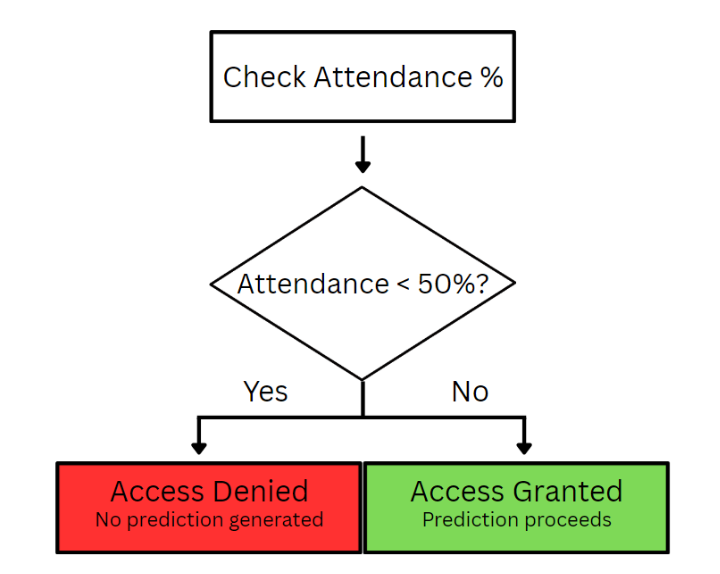

---
## 🏆 Extension: Neural Networks (Band 6 Target)
*(Optional)*: Can a deep learning "black box" beat your Linear Regression model?

**📄 Documentation Task:** Even if the Neural Network scores a better RMSE, explain why a school might still legally prefer to use Linear Regression. (Hint: Discuss the "Black Box" problem and why it is difficult to explain to a student *how* a Neural Network calculated their mark).


In [13]:
from sklearn.neural_network import MLPRegressor
print("--- Extension: Neural Network Test ---")

# TODO 1: Initialize the MLPRegressor
nn_model = MLPRegressor(hidden_layer_sizes=(16, 8), max_iter=1500, random_state=42)

# TODO 2: Train on the same scaled Level 2 data
nn_model.fit(x2_train_scaled, y_train)

# TODO 3: Predict on the scaled test data
y_pred_nn = nn_model.predict(x2_test_scaled)

# TODO 4: Calculate RMSE
RMSE_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))

# TODO 5: Compare both side by side
print(f"Level 2 Linear Regression RMSE: {RMSE_2:.4f}")
print(f"Neural Network RMSE:           {RMSE_nn:.4f}")

--- Extension: Neural Network Test ---
Level 2 Linear Regression RMSE: 5.5214
Neural Network RMSE:           2.6827


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1500) reached and the optimization hasn't converged yet.
  warnings.warn(


### Why a School Might Still Prefer Linear Regression

Even though the Neural Network scored a lower RMSE here (2.68 vs 5.52), a school would likely still choose Linear Regression for real use. Linear Regression is interpretable — the formula weight × Maths_Advanced + bias is something a student, parent, or principal could read and understand. A Neural Network's prediction comes from dozens of internal weights across multiple layers with no simple, human-readable explanation. If a parent disputed Alex's grade, the school could explain the Linear Regression's reasoning in a sentence; it couldn't do the same for the Neural Network. This is the "Black Box" problem, and it's a real reason regulators and schools tend to avoid opaque models for decisions that materially affect someone's outcome, even when those models technically score better.

##  Final Verdict: Predicting Alex's Mark

In [ ]:
print("--- Final Prediction ---")

alex_attendance = 95.0  # TODO: set this to whatever your scenario states

if check_data_reliability(alex_attendance):
    alex_data = np.array([[88, 91]])  # Alex's real Maths_Advanced, Physics
    alex_scaled = scaler.transform(alex_data)
    alex_predicted_mark = my_ai_2.predict(alex_scaled)
    print(f"Alex's predicted Software Engineering mark: {alex_predicted_mark[0]:.1f}")
else:
    print("Cannot generate a prediction — attendance data too unreliable.")

--- Final Prediction (with Reliability Check) ---
ACCESS GRANTED
Alex's predicted Software Engineering mark: 81.3
